# 01 - Data Exploration

**Project:** Multi-Agent Customer Support Intelligence Platform

This notebook performs basic exploratory data analysis (EDA) on:
- Support tickets dataset
- FAQ knowledge base

The goal is to understand the structure, quality, and basic distributions of the data before preprocessing.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

sns.set_style("whitegrid")

c:\Users\shikh\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


## 1. Define project paths using pathlib

In [6]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Raw data folder
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Dataset paths
TICKETS_PATH = DATA_DIR / "support_tickets_10k.csv"
FAQ_PATH = PROJECT_ROOT / "data" / "knowledge_base" / "faq_knowledge_base_150.csv"

print("Project Root:", PROJECT_ROOT)
print("Data Directory:", DATA_DIR)

print("\nTickets File:", TICKETS_PATH)
print("FAQ File:", FAQ_PATH)

print("\nTickets file exists:", TICKETS_PATH.exists())
print("FAQ file exists:", FAQ_PATH.exists())

Project Root: c:\Users\shikh\OneDrive\Desktop\Multi-Agent-Customer-Support-Intelligence-Platform
Data Directory: c:\Users\shikh\OneDrive\Desktop\Multi-Agent-Customer-Support-Intelligence-Platform\data\raw

Tickets File: c:\Users\shikh\OneDrive\Desktop\Multi-Agent-Customer-Support-Intelligence-Platform\data\raw\support_tickets_10k.csv
FAQ File: c:\Users\shikh\OneDrive\Desktop\Multi-Agent-Customer-Support-Intelligence-Platform\data\knowledge_base\faq_knowledge_base_150.csv

Tickets file exists: True
FAQ file exists: True


## 2. Load datasets

In [7]:
tickets = pd.read_csv(TICKETS_PATH)
faq = pd.read_csv(FAQ_PATH)

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 3. Dataset shape

In [8]:
print("Support Tickets Shape:", tickets.shape)
print("FAQ Knowledge Base Shape:", faq.shape)

Support Tickets Shape: (10000, 15)
FAQ Knowledge Base Shape: (150, 4)


## 4. First 5 rows

In [9]:
print("Support Tickets:")
display(tickets.head())

print("\nFAQ Knowledge Base:")
display(faq.head())

Support Tickets:


,ticket_id,created_date,ticket_text,product_name,product_segment,ticket_category,priority,sentiment,confidence_score,escalated,resolution_text,resolved_date,resolution_days,auto_resolved,customer_satisfaction_score
0,TKT100000,2023-08-12,The lipstick I received in order #ORD5614226 stopped working after just 5 days of use.,lipstick,Beauty & Personal Care,Product Issue,High,Negative,0.66,Yes,Full refund processed. Seller account flagged for quality investigation.,2023-08-14,2,No,1
1,TKT100001,2023-12-11,The shoe rack received in order #ORD8038374 has scratches and dents. Looks like a returned/used item.,shoe rack,Home & Kitchen,Product Issue,High,Negative,0.74,Yes,Missing accessory shipped separately at no additional cost.,2023-12-12,1,No,1
2,TKT100002,2024-01-06,I want to exchange my conditioner (order #ORD6770619) for a different size. Exchange option is missing.,conditioner,Beauty & Personal Care,Refund & Return,Low,Positive,0.93,No,Accidental order refund approved. Amount credited within 2 days.,2024-01-16,10,Yes,4
3,TKT100003,2024-11-17,My makeup brush set from order #ORD4823498 appears to be counterfeit/fake. Not the original brand.,makeup brush set,Beauty & Personal Care,Product Issue,High,Very Negative,0.78,Yes,Missing accessory shipped separately at no additional cost.,2024-11-20,3,No,1
4,TKT100004,2023-08-23,Product listing for lipstick is completely misleading. The actual product is nothing like the photos.,lipstick,Beauty & Personal Care,Product Issue,Medium,Neutral,0.94,No,Replacement lipstick dispatched after quality team verification.,2023-08-24,1,No,4



FAQ Knowledge Base:


,faq_id,question,answer,category
0,FAQ001,How do I track my order?,Go to My Orders > Select Order > Track Package for real-time courier updates.,Delivery Issue
1,FAQ002,What should I do if my order is delayed?,"Check tracking first. If no update for 48 hours, raise a complaint via My Orders > Help.",Delivery Issue
2,FAQ003,Can I change my delivery address after placing an order?,"Yes, before dispatch. Go to My Orders > Order Details > Edit Address.",Delivery Issue
3,FAQ004,What happens if I miss my delivery?,Courier will reattempt delivery. You can also reschedule via the tracking link.,Delivery Issue
4,FAQ005,How do I reschedule my delivery?,Use the tracking link in your SMS/email to select a new delivery slot.,Delivery Issue


## 5. Last 5 rows

In [10]:
print("Support Tickets:")
display(tickets.tail())

print("\nFAQ Knowledge Base:")
display(faq.tail())

Support Tickets:


,ticket_id,created_date,ticket_text,product_name,product_segment,ticket_category,priority,sentiment,confidence_score,escalated,resolution_text,resolved_date,resolution_days,auto_resolved,customer_satisfaction_score
9995,TKT109995,2024-08-03,The return window for my sofa set order #ORD2933395 was closed without my knowledge. Please make an exception.,sofa set,Home & Kitchen,Refund & Return,High,Very Negative,0.72,Yes,Seller notified of return in transit. Refund released on priority basis.,2024-08-05,2,No,1
9996,TKT109996,2024-08-20,Size/color of sofa set in order #ORD4264291 does not match what was shown on the website.,sofa set,Home & Kitchen,Product Issue,Medium,Neutral,0.88,No,Compatibility issue noted. Full refund processed. Listing updated.,2024-08-26,6,No,5
9997,TKT109997,2023-06-28,I was charged in USD instead of INR for my sunglasses order #ORD7372350. Currency conversion not expected.,sunglasses,Fashion,Payment Issue,Low,Positive,0.73,No,Payment failure investigated. Order confirmed manually. No re-charge needed.,2023-06-30,2,No,4
9998,TKT109998,2024-12-01,Order #ORD4942826 (LEGO set) is stuck in transit for 6 days. No movement on tracking at all.,LEGO set,Toys & Games,Delivery Issue,Medium,Neutral,0.83,No,Replacement dispatched with priority shipping. New tracking ID shared via SMS.,2024-12-10,9,No,4
9999,TKT109999,2023-05-11,My account is blocked/suspended without any explanation. I have not violated any policy.,formal shirt,Fashion,Account & Login,High,Negative,0.97,No,Session persistence bug escalated to tech team. Temporary fix applied.,2023-05-18,7,No,3



FAQ Knowledge Base:


,faq_id,question,answer,category
145,FAQ146,What is a lightning deal?,Lightning deals are time-limited discounts available for a set quantity. Act fast before they expire.,Payment Issue
146,FAQ147,How to report a price error on a listing?,"Go to product page > Report an Issue > Incorrect Price, and our catalog team will review.",Seller & Product Listing
147,FAQ148,What if seller cancels my order?,"If a seller cancels, you get a full refund and we may offer a compensation coupon.",Seller & Product Listing
148,FAQ149,How to become a seller on the platform?,Visit our Seller Central page and complete the registration with GST details and bank account.,Seller & Product Listing
149,FAQ150,What is the platform's commission to sellers?,Commission varies by category from 2% to 15%. Full fee structure is on Seller Central.,Seller & Product Listing


## 6. Column names

In [11]:
print("Support Ticket Columns:")
print(tickets.columns.tolist())

print("\nFAQ Columns:")
print(faq.columns.tolist())

Support Ticket Columns:
['ticket_id', 'created_date', 'ticket_text', 'product_name', 'product_segment', 'ticket_category', 'priority', 'sentiment', 'confidence_score', 'escalated', 'resolution_text', 'resolved_date', 'resolution_days', 'auto_resolved', 'customer_satisfaction_score']

FAQ Columns:
['faq_id', 'question', 'answer', 'category']


## 7. Data types

In [12]:
print("Support Tickets Data Types:")
display(tickets.dtypes)

print("\nFAQ Data Types:")
display(faq.dtypes)

Support Tickets Data Types:


ticket_id                       object
created_date                    object
ticket_text                     object
product_name                    object
product_segment                 object
ticket_category                 object
priority                        object
sentiment                       object
confidence_score               float64
escalated                       object
resolution_text                 object
resolved_date                   object
resolution_days                  int64
auto_resolved                   object
customer_satisfaction_score      int64
dtype: object


FAQ Data Types:


faq_id      object
question    object
answer      object
category    object
dtype: object

## 8. Dataset information

In [13]:
print("===== SUPPORT TICKETS =====")
tickets.info()

print("\n===== FAQ KNOWLEDGE BASE =====")
faq.info()

===== SUPPORT TICKETS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    10000 non-null  object 
 1   created_date                 10000 non-null  object 
 2   ticket_text                  10000 non-null  object 
 3   product_name                 10000 non-null  object 
 4   product_segment              10000 non-null  object 
 5   ticket_category              10000 non-null  object 
 6   priority                     10000 non-null  object 
 7   sentiment                    10000 non-null  object 
 8   confidence_score             10000 non-null  float64
 9   escalated                    10000 non-null  object 
 10  resolution_text              10000 non-null  object 
 11  resolved_date                10000 non-null  object 
 12  resolution_days              10000 non-null  in

## 9. Statistical summary

In [14]:
print("Support Tickets:")
display(tickets.describe(include="all"))

print("\nFAQ Knowledge Base:")
display(faq.describe(include="all"))

Support Tickets:


,ticket_id,created_date,ticket_text,product_name,product_segment,ticket_category,priority,sentiment,confidence_score,escalated,resolution_text,resolved_date,resolution_days,auto_resolved,customer_satisfaction_score
count,10000,10000,10000,10000,10000,10000,10000,10000,10000.000000,10000,10000,10000,10000.000000,10000,10000.000000
unique,10000,730,8777,130,8,7,3,5,NaN,2,2420,738,NaN,2,NaN
top,TKT100000,2023-09-09,My cart items keep disappearing when I switch between the app and website.,lipstick,Electronics,Refund & Return,High,Negative,NaN,No,Replacement dispatched without requiring return of defective item.,2024-02-18,NaN,No,NaN
freq,1,27,70,97,1573,2051,4620,3077,NaN,6622,226,32,NaN,9304,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.818234,NaN,NaN,NaN,4.815200,NaN,3.399900
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.098229,NaN,NaN,NaN,2.615709,NaN,1.266862
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.650000,NaN,NaN,NaN,1.000000,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.730000,NaN,NaN,NaN,3.000000,NaN,3.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.820000,NaN,NaN,NaN,5.000000,NaN,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.900000,NaN,NaN,NaN,7.000000,NaN,4.000000



FAQ Knowledge Base:


,faq_id,question,answer,category
count,150,150,150,150
unique,150,150,150,7
top,FAQ001,How do I track my order?,Go to My Orders > Select Order > Track Package for real-time courier updates.,Product Issue
freq,1,1,1,27


## 10. Missing values

In [15]:
print("===== SUPPORT TICKETS =====")

ticket_missing = pd.DataFrame({
    "Missing Values": tickets.isnull().sum(),
    "Missing Percentage": tickets.isnull().mean() * 100
})

display(ticket_missing)

print("\n===== FAQ KNOWLEDGE BASE =====")

faq_missing = pd.DataFrame({
    "Missing Values": faq.isnull().sum(),
    "Missing Percentage": faq.isnull().mean() * 100
})

display(faq_missing)

===== SUPPORT TICKETS =====


,Missing Values,Missing Percentage
ticket_id,0,0.0
created_date,0,0.0
ticket_text,0,0.0
product_name,0,0.0
product_segment,0,0.0
ticket_category,0,0.0
priority,0,0.0
sentiment,0,0.0
confidence_score,0,0.0
escalated,0,0.0



===== FAQ KNOWLEDGE BASE =====


,Missing Values,Missing Percentage
faq_id,0,0.0
question,0,0.0
answer,0,0.0
category,0,0.0


## 11. Duplicate records

In [16]:
print("Duplicate rows in Support Tickets:", tickets.duplicated().sum())
print("Duplicate rows in FAQ:", faq.duplicated().sum())

print("\nDuplicate Ticket IDs:", tickets["ticket_id"].duplicated().sum())
print("Duplicate FAQ IDs:", faq["faq_id"].duplicated().sum())

Duplicate rows in Support Tickets: 0
Duplicate rows in FAQ: 0

Duplicate Ticket IDs: 0
Duplicate FAQ IDs: 0


## 12. Number of unique values

In [17]:
print("Support Tickets:")
display(tickets.nunique())

print("\nFAQ Knowledge Base:")
display(faq.nunique())

Support Tickets:


ticket_id                      10000
created_date                     730
ticket_text                     8777
product_name                     130
product_segment                    8
ticket_category                    7
priority                           3
sentiment                          5
confidence_score                  35
escalated                          2
resolution_text                 2420
resolved_date                    738
resolution_days                   10
auto_resolved                      2
customer_satisfaction_score        5
dtype: int64


FAQ Knowledge Base:


faq_id      150
question    150
answer      150
category      7
dtype: int64

## 13. Unique values of categorical columns

In [18]:
categorical_columns = tickets.select_dtypes(include="object").columns

for column in categorical_columns:
    print("=" * 60)
    print(column)
    print("=" * 60)
    print(tickets[column].unique())
    print()

ticket_id
['TKT100000' 'TKT100001' 'TKT100002' ... 'TKT109997' 'TKT109998'
 'TKT109999']

created_date
['2023-08-12' '2023-12-11' '2024-01-06' '2024-11-17' '2023-08-23'
 '2023-09-27' '2024-09-02' '2023-06-11' '2024-07-06' '2024-06-29'
 '2024-03-24' '2023-12-05' '2023-12-29' '2024-04-18' '2024-02-15'
 '2024-08-16' '2024-02-18' '2023-05-15' '2023-09-08' '2023-10-06'
 '2024-10-14' '2024-01-09' '2024-02-27' '2023-12-25' '2023-09-25'
 '2023-01-02' '2024-02-17' '2024-11-19' '2023-06-01' '2024-03-12'
 '2023-10-20' '2024-03-01' '2024-05-12' '2024-04-17' '2023-02-23'
 '2024-01-13' '2023-04-15' '2024-03-19' '2023-10-13' '2024-12-19'
 '2023-04-06' '2023-11-10' '2024-09-03' '2024-10-15' '2024-05-18'
 '2024-04-06' '2023-03-18' '2024-11-08' '2024-12-17' '2024-08-24'
 '2023-12-23' '2023-11-28' '2023-05-20' '2023-12-20' '2024-01-31'
 '2024-02-24' '2024-07-08' '2023-02-17' '2024-09-26' '2023-10-09'
 '2023-11-13' '2024-05-08' '2023-01-15' '2024-12-18' '2024-03-05'
 '2024-07-11' '2024-08-01' '2023-05-14'

## 14. Ticket category distribution

ticket_category
Refund & Return             2051
Delivery Issue              1950
Product Issue               1948
Payment Issue               1474
Account & Login             1030
Seller & Product Listing     830
App & Website Issue          717
Name: count, dtype: int64

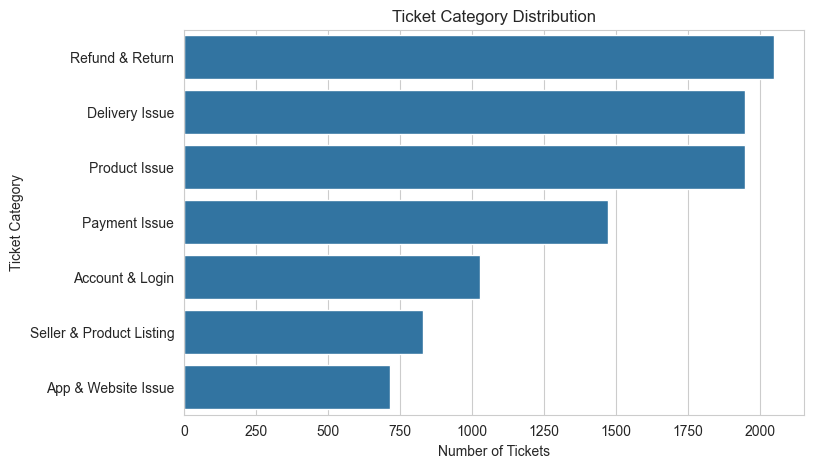

In [19]:
category_counts = tickets["ticket_category"].value_counts()

display(category_counts)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=tickets,
    y="ticket_category",
    order=category_counts.index
)
plt.title("Ticket Category Distribution")
plt.xlabel("Number of Tickets")
plt.ylabel("Ticket Category")
plt.show()

## 15. Priority distribution

priority
High      4620
Medium    3657
Low       1723
Name: count, dtype: int64

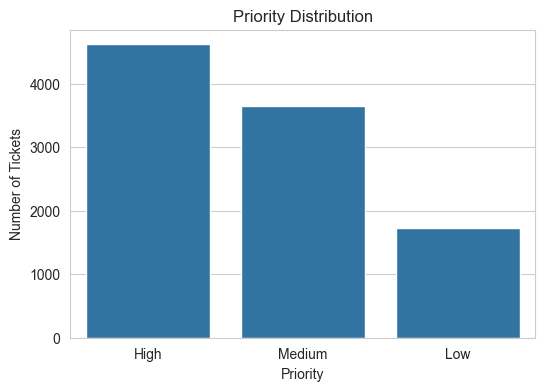

In [20]:
priority_counts = tickets["priority"].value_counts()

display(priority_counts)

plt.figure(figsize=(6, 4))
sns.countplot(
    data=tickets,
    x="priority",
    order=priority_counts.index
)
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

## 16. Sentiment distribution

sentiment
Negative             3077
Neutral              2732
Slightly Negative    1800
Very Negative        1543
Positive              848
Name: count, dtype: int64

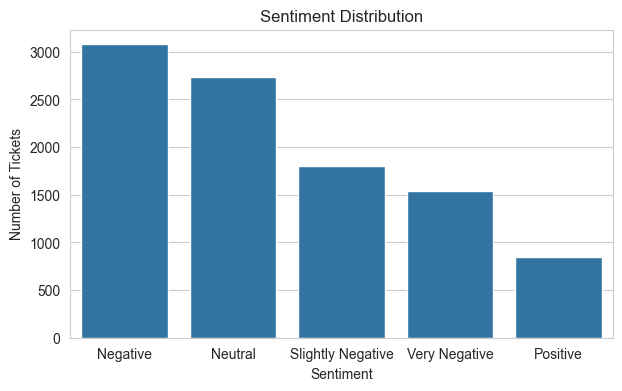

In [21]:
sentiment_counts = tickets["sentiment"].value_counts()

display(sentiment_counts)

plt.figure(figsize=(7, 4))
sns.countplot(
    data=tickets,
    x="sentiment",
    order=sentiment_counts.index
)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tickets")
plt.show()

## 17. Escalation distribution

escalated
No     6622
Yes    3378
Name: count, dtype: int64

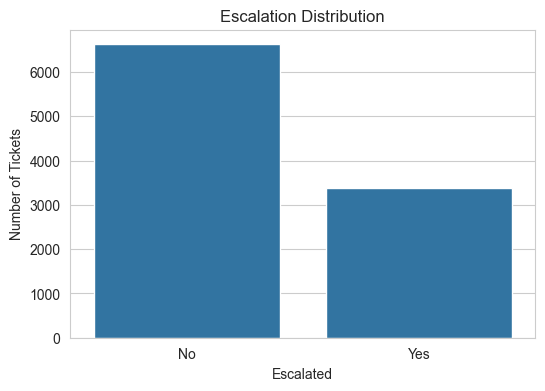

In [22]:
escalation_counts = tickets["escalated"].value_counts()

display(escalation_counts)

plt.figure(figsize=(6, 4))
sns.countplot(
    data=tickets,
    x="escalated",
    order=escalation_counts.index
)
plt.title("Escalation Distribution")
plt.xlabel("Escalated")
plt.ylabel("Number of Tickets")
plt.show()

## 18. Auto-resolution distribution

auto_resolved
No     9304
Yes     696
Name: count, dtype: int64

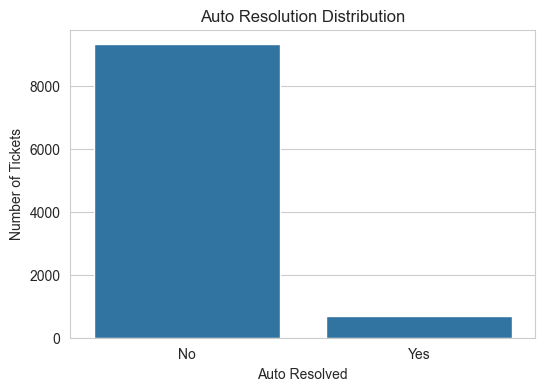

In [23]:
auto_resolved_counts = tickets["auto_resolved"].value_counts()

display(auto_resolved_counts)

plt.figure(figsize=(6, 4))
sns.countplot(
    data=tickets,
    x="auto_resolved",
    order=auto_resolved_counts.index
)
plt.title("Auto Resolution Distribution")
plt.xlabel("Auto Resolved")
plt.ylabel("Number of Tickets")
plt.show()

## 19. Product distribution

product_name
lipstick              97
soft toy              96
atta (wheat flour)    93
yoga mat              92
bluetooth speaker     92
                      ..
LED TV                62
cricket bat           61
dining table          59
instant noodles       56
self-help book        51
Name: count, Length: 130, dtype: int64

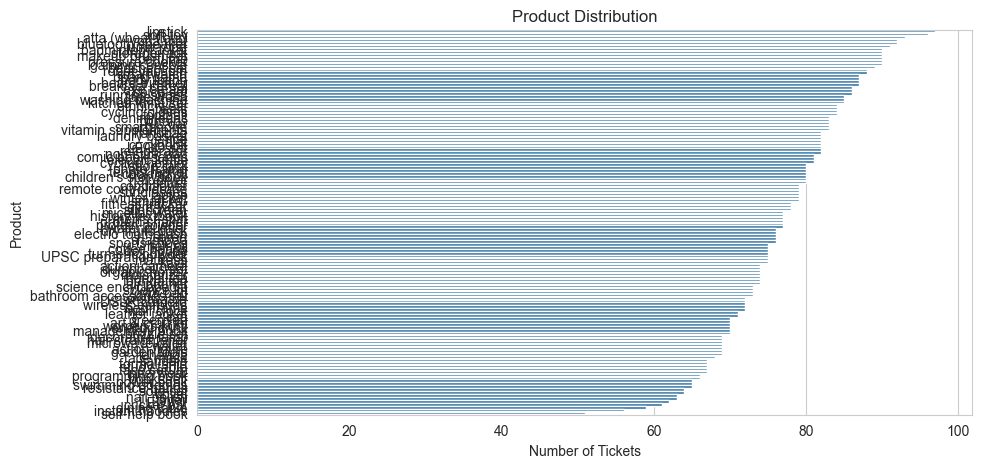

In [24]:
product_counts = tickets["product_name"].value_counts()

display(product_counts)

plt.figure(figsize=(10, 5))
sns.countplot(
    data=tickets,
    y="product_name",
    order=product_counts.index
)
plt.title("Product Distribution")
plt.xlabel("Number of Tickets")
plt.ylabel("Product")
plt.show()

## 20. Numerical feature summary

In [25]:
numerical_columns = tickets.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

display(tickets[numerical_columns].describe())

Numerical columns:
['confidence_score', 'resolution_days', 'customer_satisfaction_score']


,confidence_score,resolution_days,customer_satisfaction_score
count,10000.000000,10000.000000,10000.000000
mean,0.818234,4.815200,3.399900
std,0.098229,2.615709,1.266862
min,0.650000,1.000000,1.000000
25%,0.730000,3.000000,3.000000
50%,0.820000,5.000000,4.000000
75%,0.900000,7.000000,4.000000
max,0.990000,10.000000,5.000000


## 21. Numerical feature distributions

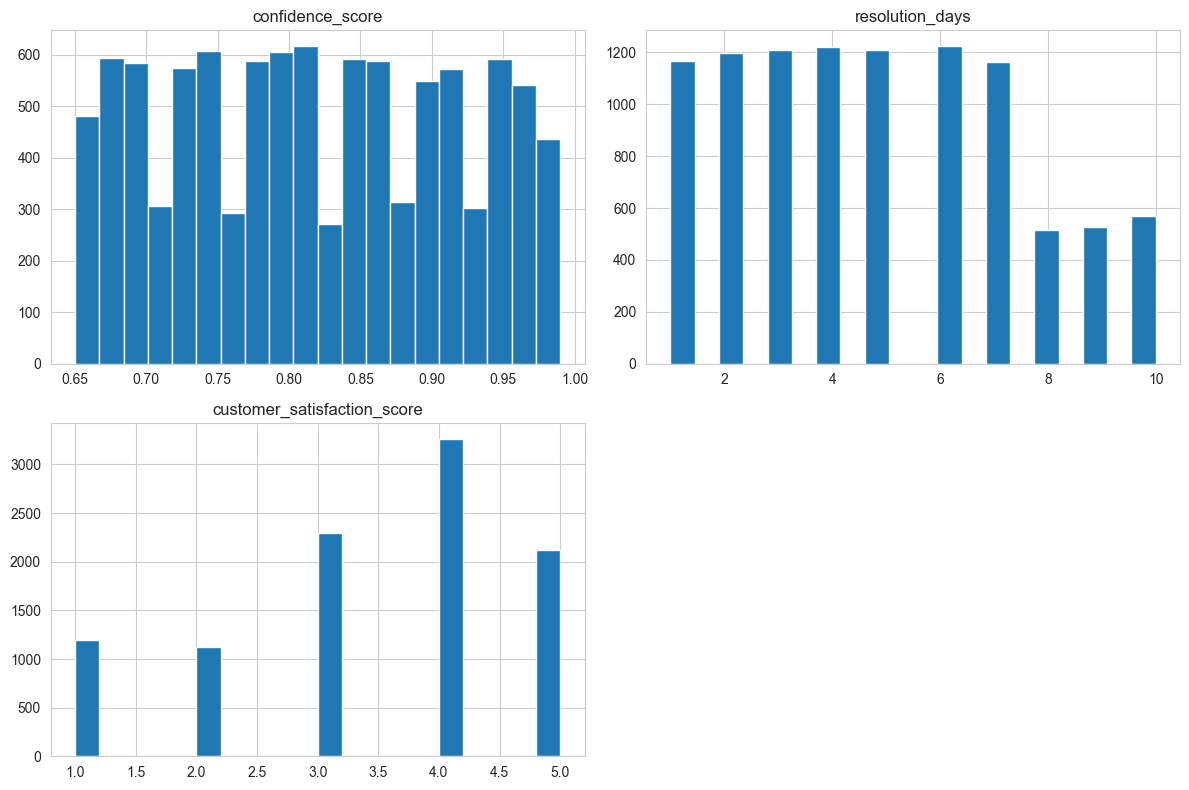

In [26]:
tickets[numerical_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

## 22. Sample support tickets

In [27]:
display(
    tickets[
        [
            "ticket_id",
            "ticket_text",
            "ticket_category",
            "priority",
            "sentiment"
        ]
    ].head(10)
)

,ticket_id,ticket_text,ticket_category,priority,sentiment
0,TKT100000,The lipstick I received in order #ORD5614226 stopped working after just 5 days of use.,Product Issue,High,Negative
1,TKT100001,The shoe rack received in order #ORD8038374 has scratches and dents. Looks like a returned/used item.,Product Issue,High,Negative
2,TKT100002,I want to exchange my conditioner (order #ORD6770619) for a different size. Exchange option is missing.,Refund & Return,Low,Positive
3,TKT100003,My makeup brush set from order #ORD4823498 appears to be counterfeit/fake. Not the original brand.,Product Issue,High,Very Negative
4,TKT100004,Product listing for lipstick is completely misleading. The actual product is nothing like the photos.,Product Issue,Medium,Neutral
5,TKT100005,EMI option for my protein powder (order #ORD4539704) is showing wrong monthly amount. Please correct it.,Payment Issue,High,Very Negative
6,TKT100006,Fake reviews on the shoe rack I bought misled me into purchasing. Quality is very poor.,Seller & Product Listing,Medium,Neutral
7,TKT100007,The quality check team rejected my perfume return (order #ORD9877065) unfairly. Item has factory defect.,Refund & Return,High,Negative
8,TKT100008,My cart items keep disappearing when I switch between the app and website.,App & Website Issue,Medium,Neutral
9,TKT100009,The color of sandals (order #ORD1326765) is completely different from what is shown online. Dark vs light.,Product Issue,Medium,Neutral


## 23. Sample resolutions

In [28]:
display(
    tickets[
        [
            "ticket_text",
            "resolution_text"
        ]
    ].head(10)
)

,ticket_text,resolution_text
0,The lipstick I received in order #ORD5614226 stopped working after just 5 days of use.,Full refund processed. Seller account flagged for quality investigation.
1,The shoe rack received in order #ORD8038374 has scratches and dents. Looks like a returned/used item.,Missing accessory shipped separately at no additional cost.
2,I want to exchange my conditioner (order #ORD6770619) for a different size. Exchange option is missing.,Accidental order refund approved. Amount credited within 2 days.
3,My makeup brush set from order #ORD4823498 appears to be counterfeit/fake. Not the original brand.,Missing accessory shipped separately at no additional cost.
4,Product listing for lipstick is completely misleading. The actual product is nothing like the photos.,Replacement lipstick dispatched after quality team verification.
5,EMI option for my protein powder (order #ORD4539704) is showing wrong monthly amount. Please correct it.,EMI plan restored to original terms. Difference amount adjusted.
6,Fake reviews on the shoe rack I bought misled me into purchasing. Quality is very poor.,Seller listing flagged for review. Customer compensated with ₹8547 coupon.
7,The quality check team rejected my perfume return (order #ORD9877065) unfairly. Item has factory defect.,Exchange processed for correct size/variant. New item dispatched.
8,My cart items keep disappearing when I switch between the app and website.,App cache clear resolved the issue. Customer guided through fix.
9,The color of sandals (order #ORD1326765) is completely different from what is shown online. Dark vs light.,Full refund processed. Seller account flagged for quality investigation.


## 24. FAQ category distribution

category
Product Issue               27
Account & Login             27
Payment Issue               24
Delivery Issue              22
Refund & Return             18
App & Website Issue         17
Seller & Product Listing    15
Name: count, dtype: int64

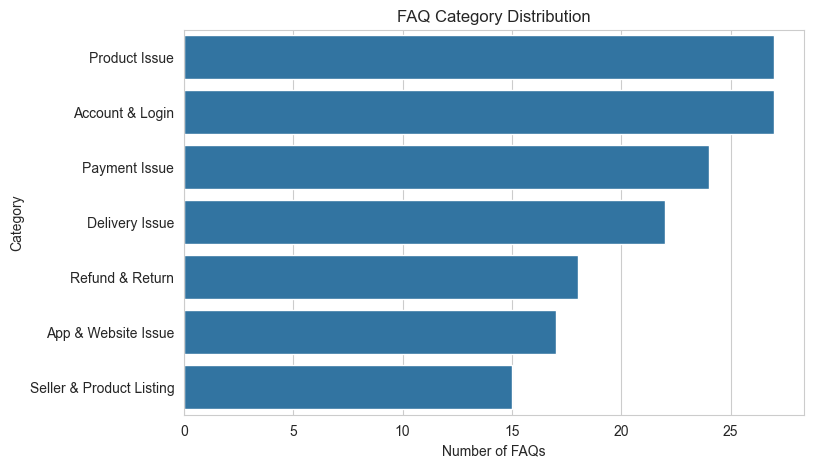

In [29]:
faq_category_counts = faq["category"].value_counts()

display(faq_category_counts)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=faq,
    y="category",
    order=faq_category_counts.index
)
plt.title("FAQ Category Distribution")
plt.xlabel("Number of FAQs")
plt.ylabel("Category")
plt.show()

## 25. Sample FAQs

In [30]:
display(
    faq[
        [
            "faq_id",
            "question",
            "answer",
            "category"
        ]
    ].head(10)
)

,faq_id,question,answer,category
0,FAQ001,How do I track my order?,Go to My Orders > Select Order > Track Package for real-time courier updates.,Delivery Issue
1,FAQ002,What should I do if my order is delayed?,"Check tracking first. If no update for 48 hours, raise a complaint via My Orders > Help.",Delivery Issue
2,FAQ003,Can I change my delivery address after placing an order?,"Yes, before dispatch. Go to My Orders > Order Details > Edit Address.",Delivery Issue
3,FAQ004,What happens if I miss my delivery?,Courier will reattempt delivery. You can also reschedule via the tracking link.,Delivery Issue
4,FAQ005,How do I reschedule my delivery?,Use the tracking link in your SMS/email to select a new delivery slot.,Delivery Issue
5,FAQ006,What if my package shows delivered but I didn't receive it?,Raise a complaint within 48 hours via My Orders > Report > Item Not Received.,Delivery Issue
6,FAQ007,Can I request a specific delivery time?,You can choose a preferred slot during checkout if available in your pin code.,Delivery Issue
7,FAQ008,What if my package is damaged on arrival?,"Do not accept if visibly damaged. If opened and damaged, report via My Orders within 48 hours.",Delivery Issue
8,FAQ009,Why was my order returned to seller?,This happens after failed delivery attempts. Contact support to reship or get refund.,Delivery Issue
9,FAQ010,Do you deliver to all pin codes in India?,"We deliver to 27,000+ pin codes. Enter your pin code on product page to check availability.",Delivery Issue


## 26. Basic EDA summary

In [31]:
print("===== SUPPORT TICKETS =====")
print("Rows:", tickets.shape[0])
print("Columns:", tickets.shape[1])
print("Duplicate rows:", tickets.duplicated().sum())
print("Total missing values:", tickets.isnull().sum().sum())

print("\n===== FAQ KNOWLEDGE BASE =====")
print("Rows:", faq.shape[0])
print("Columns:", faq.shape[1])
print("Duplicate rows:", faq.duplicated().sum())
print("Total missing values:", faq.isnull().sum().sum())

===== SUPPORT TICKETS =====
Rows: 10000
Columns: 15
Duplicate rows: 0
Total missing values: 0

===== FAQ KNOWLEDGE BASE =====
Rows: 150
Columns: 4
Duplicate rows: 0
Total missing values: 0
